chargement des librairies presentes dans le fichier src/imports.py

In [2]:
import sys
sys.path.append('..')
from src.imports import *

chargement du dataset

In [8]:
df = pd.read_csv("../data/raw/cybersecurity_intrusion_data.csv")

apercu du dataset

In [21]:
df.head(10)

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
5,SID_00006,453,UDP,5,380.471550,AES,0.422486,2,Chrome,1,0
6,SID_00007,815,ICMP,4,728.107165,AES,0.413772,1,Chrome,0,1
7,SID_00008,653,TCP,3,12.599906,DES,0.097719,3,Chrome,1,1
8,SID_00009,406,TCP,2,542.558895,NaN,0.294580,0,Chrome,1,0
9,SID_00010,608,UDP,6,531.944107,NaN,0.424117,1,Chrome,0,0


taille du dataset

In [5]:
df.shape

(9537, 11)

types de variables dans le dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


pourcentages des variables manquantes 

In [7]:
((df.isnull().sum()/len(df))*100).sort_values(ascending=False)

encryption_used        20.614449
network_packet_size     0.000000
session_id              0.000000
protocol_type           0.000000
login_attempts          0.000000
session_duration        0.000000
ip_reputation_score     0.000000
failed_logins           0.000000
browser_type            0.000000
unusual_time_access     0.000000
attack_detected         0.000000
dtype: float64

verification des doublons 

In [8]:
df.duplicated().sum()

np.int64(0)

Identifer les variables numériques et catégorielles.

pourcentages de repartition de la variables cible

In [9]:
(df["attack_detected"].value_counts()/len(df))*100  

attack_detected
0    55.289923
1    44.710077
Name: count, dtype: float64

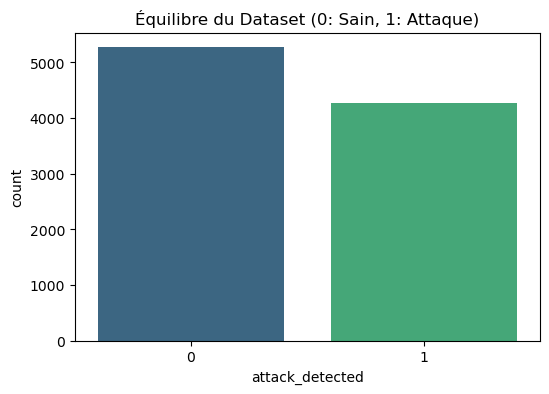

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='attack_detected', data=df, hue='attack_detected', palette='viridis', legend=False)
plt.title("Équilibre du Dataset (0: Sain, 1: Attaque)")
plt.show()

Statistiques descriptives

In [10]:
df.drop(columns=['attack_detected']).describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000


recuperation des collones categorielles 

In [11]:
colonne_categorielle = df.select_dtypes(include=['object']).columns

Analyse des variables catégorielles

In [12]:
for i in colonne_categorielle:
    print(df[i].value_counts())

session_id
SID_09537    1
SID_09521    1
SID_09520    1
SID_09519    1
SID_09518    1
            ..
SID_00006    1
SID_00005    1
SID_00004    1
SID_00003    1
SID_00002    1
Name: count, Length: 9537, dtype: int64
protocol_type
TCP     6624
UDP     2406
ICMP     507
Name: count, dtype: int64
encryption_used
AES    4706
DES    2865
Name: count, dtype: int64
browser_type
Chrome     5137
Firefox    1944
Edge       1469
Unknown     502
Safari      485
Name: count, dtype: int64


Distribution des variables numériques

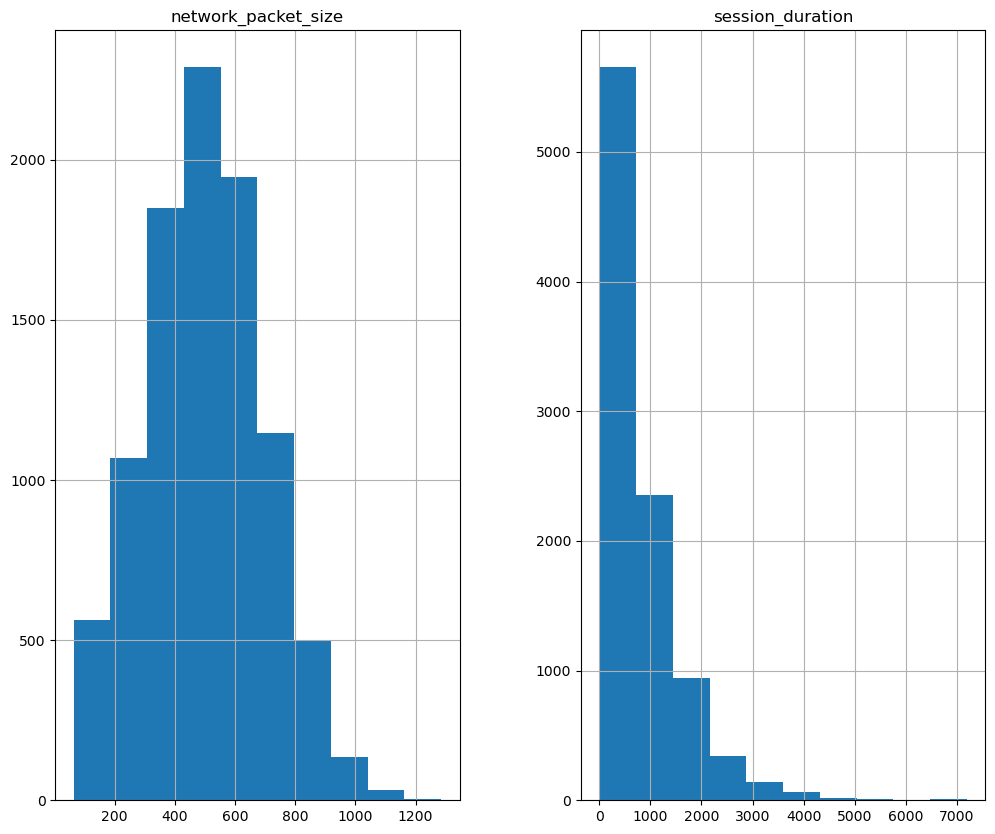

In [14]:
df.drop(columns=['attack_detected', 'login_attempts', 'ip_reputation_score', 'failed_logins', 'unusual_time_access']).hist(figsize=(12,10))
plt.show()

Diagramme des protocoles (protocol_type).


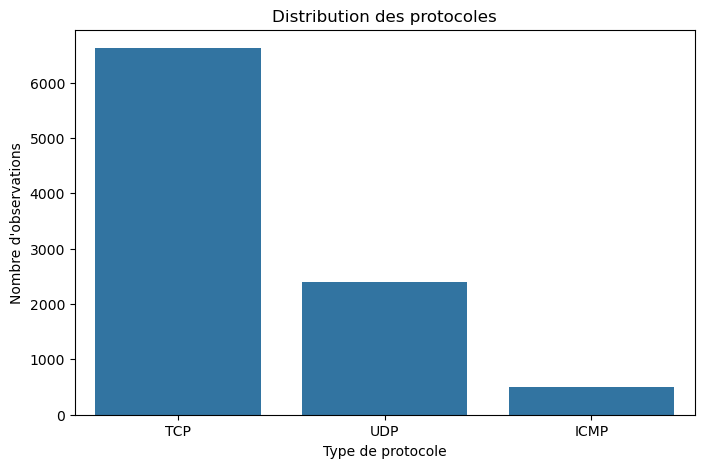

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='protocol_type', order=df['protocol_type'].value_counts().index)

plt.title('Distribution des protocoles')
plt.xlabel('Type de protocole')
plt.ylabel("Nombre d'observations")

plt.show()

Répartition des navigateurs (browser_type).


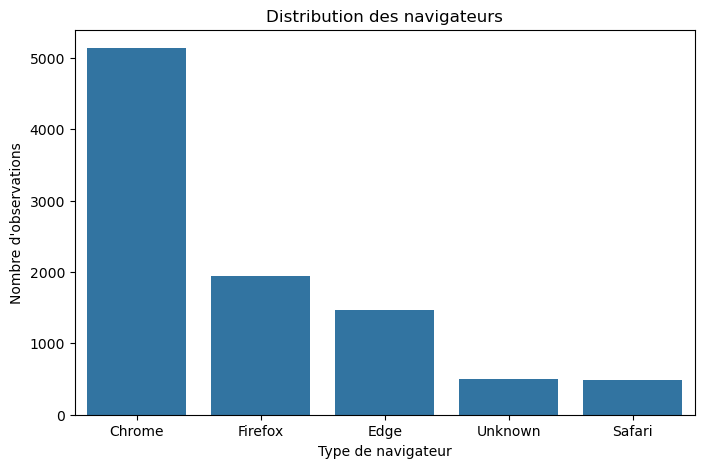

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='browser_type', order=df['browser_type'].value_counts().index)

plt.title('Distribution des navigateurs')
plt.xlabel('Type de navigateur')
plt.ylabel("Nombre d'observations")

plt.show()

Distribution de encryption_used

<Axes: xlabel='encryption_used'>

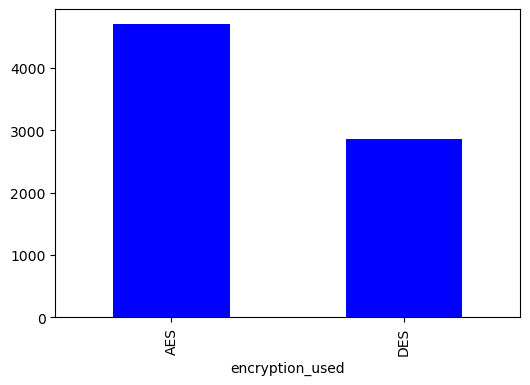

In [16]:
df['encryption_used'].value_counts().plot(kind='bar', figsize=(6, 4), color='blue')

Matrice de corrélation 

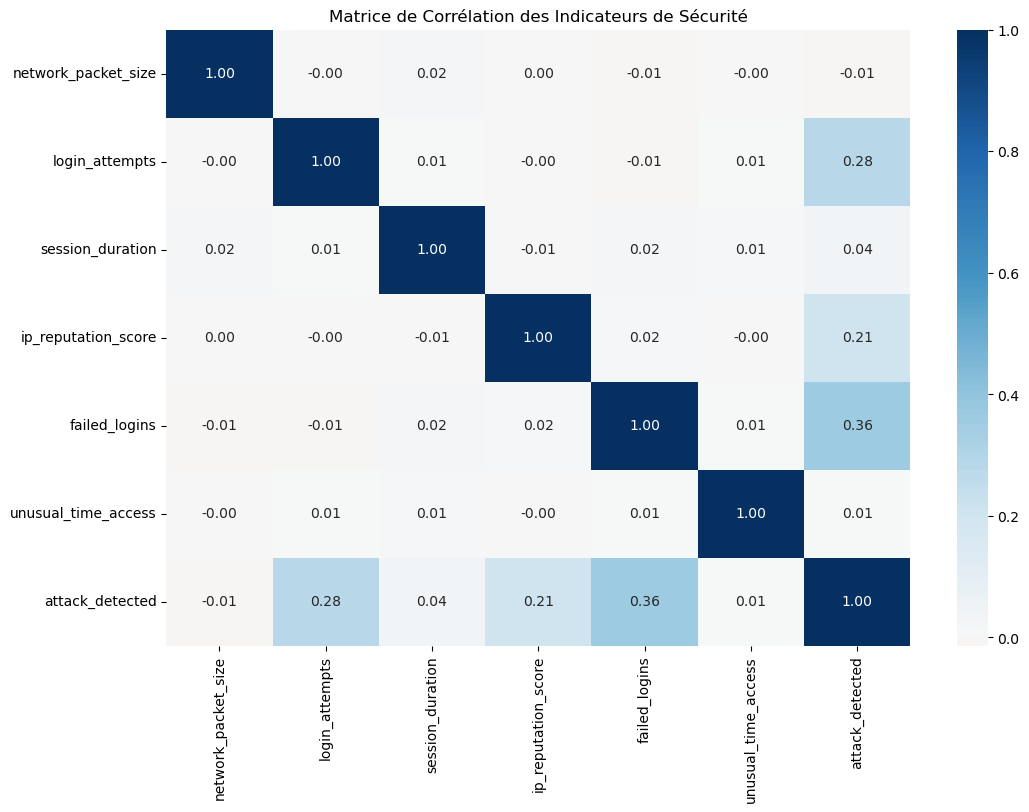

In [ ]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title("Matrice de Corrélation des Indicateurs de Sécurité")
plt.show()

Boxplots de :failed_logins, login_attempts, ip_reputation_score.


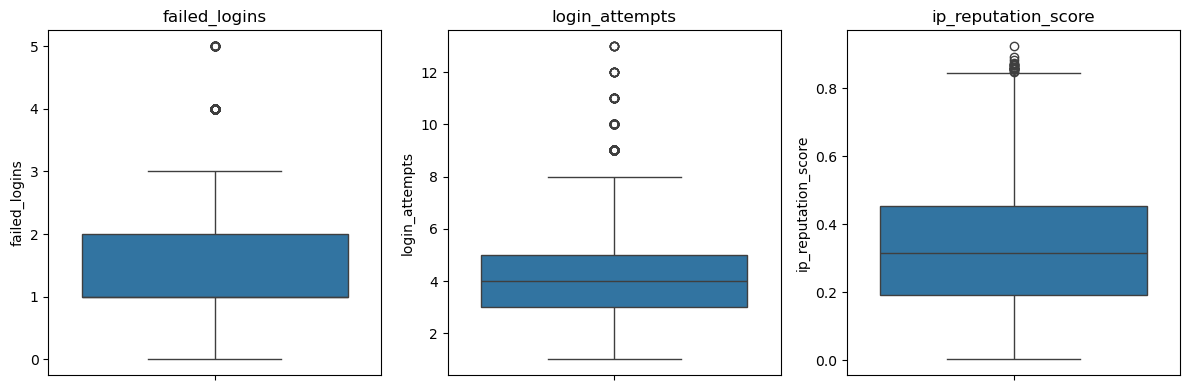

In [17]:
# Liste des variables
variables = ['failed_logins', 'login_attempts', 'ip_reputation_score']

# Création des boxplots
plt.figure(figsize=(12,4))

for i, var in enumerate(variables):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[var])
    plt.title(var)

plt.tight_layout()
plt.show()

Les utilisateurs attaquants présentent-ils davantage de tentatives de connexion échouées ?


<Axes: xlabel='attack_detected'>

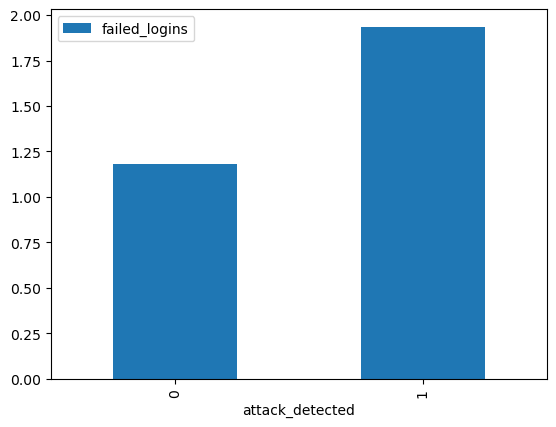

In [30]:
df.groupby('attack_detected')['failed_logins'].mean().plot(kind='bar', legend=True)

Les connexions à des heures inhabituelles sont-elles plus souvent associées à des attaques ?


In [ ]:
attack_by_hour = pd.crosstab(
    df['unusual_time_access'],
    df['attack_detected'],
    normalize='index'
)
    
attack_by_hour

attack_detected,0,1
unusual_time_access,,
0,0.554706,0.445294
1,0.542657,0.457343
